# Preliminary Exploratory Data Analysis — PGT-A Dataset

---

**4/10/2026 — N.Q.**

This notebook aims to conduct initial exploratory data analysis on the PGT-A dataset.  
This includes outlier detection, understanding distributions, checking for missing data, inconsistencies, etc.

---

## 1. Load Libraries & Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Raw dataset is not included in this repo (restricted patient-level data).
# Place ccrm_dataset.csv in a local data/ directory to reproduce this notebook.
original = pd.read_csv("data/ccrm_dataset.csv")
original

,patient_ID,embryo_ID,number_of_embryos,CCS_result,CCS_interpretation,maternal_age,paternal_age,morphology,embryo_age,sex,file_name,path
0,1468,1,5,46XX,Normal,34,*,5AA,5,XX,JTR8W-10-0342-10-BST1_S20_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
1,1468,2,5,46XX,Normal,34,*,3AB,5,XX,JTR8W-10-0342-10-BST2_S21_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
2,1468,3,5,"45XY, -16",Abnormal,34,*,6BB,6,XY,JTR8W-10-0342-10-BST3_S22_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
3,1468,4,5,46XX,Normal,34,*,6BA,6,XX,JTR8W-10-0342-10-BST4_S23_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
4,1468,5,5,"45XX, -22",Abnormal,34,*,3BB,6,XX,JTR8W-10-0342-10-BST5_S24_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
...,...,...,...,...,...,...,...,...,...,...,...,...
40036,7460,4,4,46XX,Normal,32,33,6BB,6,XX,LBVMF-9-2787-9-CHT4_S4_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40037,7461,1,4,"45XX, -22",Abnormal,41,41,4AA,5,XX,LBVMF-9-2789-9-CNT1_S20_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40038,7461,2,4,46XY,Normal,41,41,4AB,5,XY,LBVMF-9-2789-9-CNT2_S21_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40039,7461,3,4,"48XX, +15 +22",Abnormal,41,41,6BB,6,XX,LBVMF-9-2789-9-CNT3_S22_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...


## 2. Initial Inspection of Maternal Age

In [3]:
original["maternal_age"].describe()

count     40041
unique       33
top          34
freq       3866
Name: maternal_age, dtype: object

### 2.1 Create Working Copy & Convert Maternal Age to Numeric

Create a duplicate called `age` for all downstream manipulation.  
Convert `maternal_age` from object to numeric, coercing non-numeric entries to NaN.

In [4]:
# Create a working copy so the original remains untouched
age = original.copy()

# Convert maternal_age from object to numeric
age["maternal_age"] = pd.to_numeric(age["maternal_age"], errors="coerce")

## 3. Dominant Patient Age Group (32–38)

Filter to the most common clinical age range for PGT-A patients.

In [5]:
# Filter to patients aged 32-38 in a single boolean mask
dominantPtAgeGroupsDF = age[age["maternal_age"].between(32, 38)]
dominantPtAgeGroupsDF

,patient_ID,embryo_ID,number_of_embryos,CCS_result,CCS_interpretation,maternal_age,paternal_age,morphology,embryo_age,sex,file_name,path
0,1468,1,5,46XX,Normal,34.0,*,5AA,5,XX,JTR8W-10-0342-10-BST1_S20_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
1,1468,2,5,46XX,Normal,34.0,*,3AB,5,XX,JTR8W-10-0342-10-BST2_S21_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
2,1468,3,5,"45XY, -16",Abnormal,34.0,*,6BB,6,XY,JTR8W-10-0342-10-BST3_S22_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
3,1468,4,5,46XX,Normal,34.0,*,6BA,6,XX,JTR8W-10-0342-10-BST4_S23_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
4,1468,5,5,"45XX, -22",Abnormal,34.0,*,3BB,6,XX,JTR8W-10-0342-10-BST5_S24_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
...,...,...,...,...,...,...,...,...,...,...,...,...
40022,7458,5,4,"45XX, -7",Abnormal,37.0,35,3BB,6,XX,LB96V-9-2782-9-SCT5_S13_L001_R1_001.fastq.gz,K:/MiSeq2/MiSeqOutput/2023/December_2023/23122...
40033,7460,1,4,46XY,Normal,32.0,33,3AB,5,XY,LBVMF-9-2787-9-CHT1_S1_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40034,7460,2,4,46XY,Normal,32.0,33,3AB,5,XY,LBVMF-9-2787-9-CHT2_S2_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40035,7460,3,4,"45XX, -2",Abnormal,32.0,33,3BB,6,XX,LBVMF-9-2787-9-CHT3_S3_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...


In [6]:
numberUniqueDominant = dominantPtAgeGroupsDF["patient_ID"].nunique()
print(f"Unique patients in 32-38 age group: {numberUniqueDominant}")

Unique patients in 32-38 age group: 3598


In [7]:
print(f'Total Number of Patients: {age["patient_ID"].nunique()}')

Total Number of Patients: 5994


## 4. Identify & Export Missing Age Data

Patients with unknown maternal or paternal age are separated for later review.  
This may still be useful even without age information.

In [8]:
unknownMaternalAge = age[age["maternal_age"].isna()]
unknownPaternalAge = age[age["paternal_age"].isna()]

print(f"Rows with unknown maternal age: {len(unknownMaternalAge)}")
print(f"Rows with unknown paternal age: {len(unknownPaternalAge)}")

Rows with unknown maternal age: 1584
Rows with unknown paternal age: 30


In [9]:
unknownMaternalAge

,patient_ID,embryo_ID,number_of_embryos,CCS_result,CCS_interpretation,maternal_age,paternal_age,morphology,embryo_age,sex,file_name,path
19,1470,1,13,46XX,Normal,NaN,43,5AA,5,XX,JTPRR-10-0344-10-DKT1_S9_L001_R1_001.fastq.gz,K:/MiSeq3/MiSeqOutput/2021/October_2021/211027...
20,1470,2,13,46XX,Normal,NaN,43,5BB,5,XX,JTPRR-10-0344-10-DKT2_S10_L001_R1_001.fastq.gz,K:/MiSeq3/MiSeqOutput/2021/October_2021/211027...
21,1470,3,13,46XY,Normal,NaN,43,3BB,5,XY,JTPRR-10-0344-10-DKT3_S11_L001_R1_001.fastq.gz,K:/MiSeq3/MiSeqOutput/2021/October_2021/211027...
22,1470,4,13,46XY,Normal,NaN,43,3AB,5,XY,JTPRR-10-0344-10-DKT4_S12_L001_R1_001.fastq.gz,K:/MiSeq3/MiSeqOutput/2021/October_2021/211027...
23,1470,5,13,46XY,Normal,NaN,43,3AB,5,XY,JTPRR-10-0344-10-DKT5_S13_L001_R1_001.fastq.gz,K:/MiSeq3/MiSeqOutput/2021/October_2021/211027...
...,...,...,...,...,...,...,...,...,...,...,...,...
40028,7459,6,10,46XX,Normal,NaN,44,6AB,6,XX,LBVMF-9-2784-9-MLT6_S14_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40029,7459,7,10,46XX,Normal,NaN,44,6AA,6,XX,LBVMF-9-2784-9-MLT7_S15_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40030,7459,8,10,"45XY, -16",Abnormal,NaN,44,4BB,6,XY,LBVMF-9-2784-9-MLT8_S16_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...
40031,7459,9,10,46XY,Normal,NaN,44,3BB,6,XY,LBVMF-9-2784-9-MLT9_S17_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2023/December_2023/23122...


In [10]:
# Export unknown age subsets
unknownMaternalAge.to_csv("unknownMaternalAge.csv", index=False)
unknownMaternalAge.to_csv("unknownMaternalAge.txt", sep=",", index=False)
unknownPaternalAge.to_csv("unknownPaternalAge.csv", index=False)
unknownPaternalAge.to_csv("unknownPaternalAge.txt", sep=",", index=False)

In [11]:
# Unique patient IDs with unknown ages
print("Unknown maternal age patient IDs:", unknownMaternalAge["patient_ID"].unique())
print("Unknown paternal age patient IDs:", unknownPaternalAge["patient_ID"].unique())

Unknown maternal age patient IDs: [1470 1475 1509 1513 1535 1542 1609 1611 1693 1710 1730 1745 1762 1790
 1811 1812 1849 1859 1905 1940 1956 1968 1999 2017 2037 2046 2066 2069
 2079 2111 2112 2139 2153 2174 2197 2219 2234 2252 2254 2276 2289 2305
 2307 2319 2391 2471 2978 2979 3007 3119 3124 3128 3143 3170 3224 3249
 3315 3316 3327 3341 3342 3351 3400 3406 3438 3487 3499 3514 3515 3529
 3538 3539 3548 3564 3587 3588 3618 3675 3679 3703 3712 3713 3733 3759
 3781 3802 3811 3812 3813 3815 3825 3851 3858 3869 3892 3928 3976 4009
 4012 4015 4044 4098 4099 4108 4112 4119 4413 4502 4783 5013 5014 5019
 5040 5048 5050 5055 5085 5093 5107 5126 5144 5191 5192 5195 5216 5243
 5268 5276 5315 5323 5337 5381 5415 5420 5440 5479 5492 5500 5502 5512
 5519 5528 5544 5548 5592 5613 5664 5666 5705 5723 5724 5740 5747 5748
 5770 5804 5865 5873 5900 5902 5916 6155 6327 6423 6440 6471 6487 6498
 6511 6623 6647 6658 6810 6904 6916 6945 6947 6967 6984 6990 7011 7012
 7014 7021 7042 7084 7097 7102 7111 7124 71

## 5. Age Distribution Summary

Min age is 21, max age is 53 — all integer values

In [12]:
age["maternal_age"].describe()

count    38457.000000
mean        34.767091
std          3.897135
min         21.000000
25%         32.000000
50%         35.000000
75%         38.000000
max         53.000000
Name: maternal_age, dtype: float64

## 6. Embryo Count Distribution

In [13]:
age["number_of_embryos"].describe()

count    40041.000000
mean         7.973552
std          3.642198
min          1.000000
25%          5.000000
50%          7.000000
75%         10.000000
max         29.000000
Name: number_of_embryos, dtype: float64

## 7. Detect Patients with Inconsistent Embryo Counts

If a patient appears multiple times with different `number_of_embryos` values,  
this may indicate repeat IVF cycles or data entry issues.

**Vectorized approach:** use `groupby` + `nunique` instead of iterating over each patient ID.

In [14]:
# Old approach: looped through range(1468, 7461) checking each patient one by one
# for j in range(1468, 7461):
#     uniquePatientIDDF = age.loc[age["patient_ID"] == j]
#     length = len(uniquePatientIDDF["number_of_embryos"])
#     if length <= 1:
#         continue
#     for k in range(0, length-1):
#         currValue = uniquePatientIDDF["number_of_embryos"].iloc[k]
#         nextValue = uniquePatientIDDF["number_of_embryos"].iloc[k+1]
#         if currValue != nextValue:
#             duplicatePatientIDs.append(uniquePatientIDDF)
#             break

# Vectorized: find patients with more than one unique embryo count
embryo_nunique = age.groupby("patient_ID")["number_of_embryos"].nunique()
inconsistent_embryo_ids = embryo_nunique[embryo_nunique > 1].index

duplicatePatientIDs = [age.loc[age["patient_ID"] == pid] for pid in inconsistent_embryo_ids]
print(f"Patients with inconsistent embryo counts: {len(duplicatePatientIDs)}")

Patients with inconsistent embryo counts: 0


In [15]:
duplicatePatientIDs

[]

## 8. Detect Patients with Inconsistent Maternal Ages

Same logic — if a patient has entries with different maternal ages, flag them.

In [16]:
# Old approach: looped through range(1468, 7461) one patient at a time
# for j in range(1468, 7461):
#     uniqueMaternalAgeDF = age.loc[age["patient_ID"] == j]
#     if len(uniqueMaternalAgeDF) <= 1:
#         continue
#     if uniqueMaternalAgeDF["maternal_age"].nunique() > 1:
#         matAgeDuplicatePatientIDs.append(uniqueMaternalAgeDF)

# Vectorized: groupby + nunique
age_nunique = age.groupby("patient_ID")["maternal_age"].nunique()
inconsistent_age_ids = age_nunique[age_nunique > 1].index

matAgeDuplicatePatientIDs = [age.loc[age["patient_ID"] == pid] for pid in inconsistent_age_ids]
print(f"Patients with inconsistent maternal ages: {len(matAgeDuplicatePatientIDs)}")

Patients with inconsistent maternal ages: 2


In [17]:
# Export the first inconsistent-age patient (if any) for review
if matAgeDuplicatePatientIDs:
    matAgeDuplicatePatientIDs[0].to_csv("matAgeDifference.csv", index=False)
    matAgeDuplicatePatientIDs[0].to_csv("matAgeDifference.txt", sep=",", index=False)
    matAgeDuplicatePatientIDs[0]

## 9. Check for Duplicate Embryo IDs Within Patients

Each patient/IVF cycle should have unique embryo IDs starting at 1.  
Duplicated embryo IDs within a patient would indicate repeat cycles.

**Vectorized approach:** use `groupby` + `apply` with `duplicated`.

In [18]:
# Old approach: looped range(1468, 7461) and checked .duplicated().any() per patient
# for j in range(1468, 7461):
#     uniqueEmbryoID = age.loc[age["patient_ID"] == j]
#     if uniqueEmbryoID["embryo_ID"].duplicated().any():
#         duplicatesBasedonEmbryoID.append(uniqueEmbryoID)

# Vectorized: groupby and check for any duplicated embryo_ID within each patient
has_dup_embryo = age.groupby("patient_ID")["embryo_ID"].apply(lambda x: x.duplicated().any())
dup_embryo_ids = has_dup_embryo[has_dup_embryo].index

duplicatesBasedonEmbryoID = [age.loc[age["patient_ID"] == pid] for pid in dup_embryo_ids]
print(f"Patients with duplicate embryo IDs: {len(duplicatesBasedonEmbryoID)}")

Patients with duplicate embryo IDs: 0


No entries found with duplicated embryo IDs — consistent with single-cycle data per patient.

## 10. Patients with Extreme Embryo Counts

Examine patients with ≥20 embryos (unusually high) and patients with exactly 1 embryo.

In [19]:
ptsOverTwentyEmbryos = age.loc[age["number_of_embryos"] >= 20]
ptsOverTwentyEmbryos.to_csv("ptsOverTwentyEmbryos.csv", index=False)
ptsOverTwentyEmbryos.to_csv("ptsOverTwentyEmbryos.txt", sep=",", index=False)

ptsWithOneEmbryo = age.loc[age["number_of_embryos"] == 1]
ptsWithOneEmbryo.to_csv("ptsWithOneEmbryo.csv", index=False)
ptsWithOneEmbryo.to_csv("ptsWithOneEmbryo.txt", sep=",", index=False)

print(f"Rows with >=20 embryos: {len(ptsOverTwentyEmbryos)}")
print(f"Rows with exactly 1 embryo: {len(ptsWithOneEmbryo)}")

Rows with >=20 embryos: 422
Rows with exactly 1 embryo: 9


In [20]:
# Unique patient IDs for each extreme group
overTwenty = ptsOverTwentyEmbryos["patient_ID"].unique()
pd.Series(overTwenty).to_csv("ptsIDsOverTwenty.csv", index=False)
pd.Series(overTwenty).to_csv("ptsIDsOverTwenty.txt", sep=",", index=False)
print(f"Unique patients with >=20 embryos: {len(overTwenty)}")

oneEmbryo = ptsWithOneEmbryo["patient_ID"].unique()
pd.Series(oneEmbryo).to_csv("ptIDsOneEmbryo.txt", sep=",", index=False)
print(f"Unique patients with 1 embryo: {len(oneEmbryo)}")

Unique patients with >=20 embryos: 19
Unique patients with 1 embryo: 9


In [21]:
original.head(30)

,patient_ID,embryo_ID,number_of_embryos,CCS_result,CCS_interpretation,maternal_age,paternal_age,morphology,embryo_age,sex,file_name,path
0,1468,1,5,46XX,Normal,34,*,5AA,5,XX,JTR8W-10-0342-10-BST1_S20_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
1,1468,2,5,46XX,Normal,34,*,3AB,5,XX,JTR8W-10-0342-10-BST2_S21_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
2,1468,3,5,"45XY, -16",Abnormal,34,*,6BB,6,XY,JTR8W-10-0342-10-BST3_S22_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
3,1468,4,5,46XX,Normal,34,*,6BA,6,XX,JTR8W-10-0342-10-BST4_S23_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
4,1468,5,5,"45XX, -22",Abnormal,34,*,3BB,6,XX,JTR8W-10-0342-10-BST5_S24_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
5,1469,1,14,"45XX, -2",Abnormal,27,29,4AB,5,XX,JTRPJ-10-0343-10-AST1_S5_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211015...
6,1469,2,14,46XY,Normal,27,29,3BB,5,XY,JTRPJ-10-0343-10-AST2_S6_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211015...
7,1469,3,14,45XO,Abnormal,27,29,3BB,5,XO,JTRPJ-10-0343-10-AST3_S7_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211015...
8,1469,4,14,46XY,Normal,27,29,3AB,5,XY,JTRPJ-10-0343-10-AST4_S8_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211015...
9,1469,5,14,46XX,Normal,27,29,5BB,6,XX,JTRPJ-10-0343-10-AST5_S9_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211015...


In [22]:
# Quick check — this patient seems to have done 29 embryos at the same age in one session
age["maternal_age"].describe()

count    38457.000000
mean        34.767091
std          3.897135
min         21.000000
25%         32.000000
50%         35.000000
75%         38.000000
max         53.000000
Name: maternal_age, dtype: float64

## 11. Separate Unique Patients by Age Group

For each age 21–53, create a DataFrame of unique patients (deduplicated by `patient_ID`).

**This is important for visualization later**

**Vectorized approach:** use `groupby` instead of looping through each age.

---

As expected, we have successfully created 33 DataFrames (53 − 21 + 1) to store all the unique patients within each age group.

- `age = index + 21`
- `index = age - 21`

In [23]:
# Old approach: looped range(21, 54) filtering and deduplicating one age at a time
# separateByAge = []
# for i in range(21, 54):
#     dfSortByAge = (age.loc[age["maternal_age"] == i]).drop_duplicates(subset="patient_ID")
#     separateByAge.append(dfSortByAge)

# Vectorized: groupby age, then deduplicate within each group
separateByAge_dict = {
    mat_age: group.drop_duplicates(subset="patient_ID")
    for mat_age, group in age.dropna(subset="maternal_age").groupby("maternal_age")
    if 21 <= mat_age <= 53
}

# Convert to ordered list for backward compatibility
separateByAge = [separateByAge_dict.get(a, pd.DataFrame()) for a in range(21, 54)]

print(f"Age groups created: {len(separateByAge)}")

Age groups created: 33


## 12. Embryo Count vs. Patient Count by Age

For each age group, count how many unique patients have each embryo count (1–29).  
Produces a combined DataFrame with columns: `patient_age`, `number_of_embryos`, `pts_w_embryo_count`.

**Next steps from original notes:**
- Using each DataFrame by age, count patient totals corresponding to each # of embryos (range 1–29)
- If that specific # doesn't exist for that age group, record 0
- Store as: col 1 = totalEmbryos, col 2 = patient count

In [24]:
ages_list = list(range(21, 54))

embryoPtTotals = []
for i, df in enumerate(separateByAge):
    if df.empty:
        continue
    value_counts = df["number_of_embryos"].value_counts()
    dfEmPtTotals = value_counts.reindex(range(1, 30), fill_value=0).reset_index()
    dfEmPtTotals.columns = ["number_of_embryos", "pts_w_embryo_count"]
    dfEmPtTotals.insert(0, "patient_age", ages_list[i])
    embryoPtTotals.append(dfEmPtTotals)

fullEmbryoPtTotals = pd.concat(embryoPtTotals, ignore_index=True)
fullEmbryoPtTotals

,patient_age,number_of_embryos,pts_w_embryo_count
0,21,1,0
1,21,2,0
2,21,3,0
3,21,4,0
4,21,5,0
...,...,...,...
923,53,25,0
924,53,26,0
925,53,27,0
926,53,28,0


In [25]:
fullEmbryoPtTotals.to_csv("complete_embryoCount_vs_ptCount.csv", index=False)

## 13. Total Patient Counts by Age

In [26]:
value_counts = age["maternal_age"].value_counts()
ptsByAge = value_counts.reindex(range(21, 54), fill_value=0).reset_index()
ptsByAge.columns = ["patient_age", "total_patients"]
ptsByAge.to_csv("patient_counts_byAge.csv", index=False)
ptsByAge

,patient_age,total_patients
0,21,8
1,22,0
2,23,50
3,24,76
4,25,114
5,26,273
6,27,476
7,28,999
8,29,1382
9,30,1935


## 14. Stacked Bar Chart — Patients by Age & Embryo Count

Instead of 957 individual bars, stack embryo counts within each age group for readability.

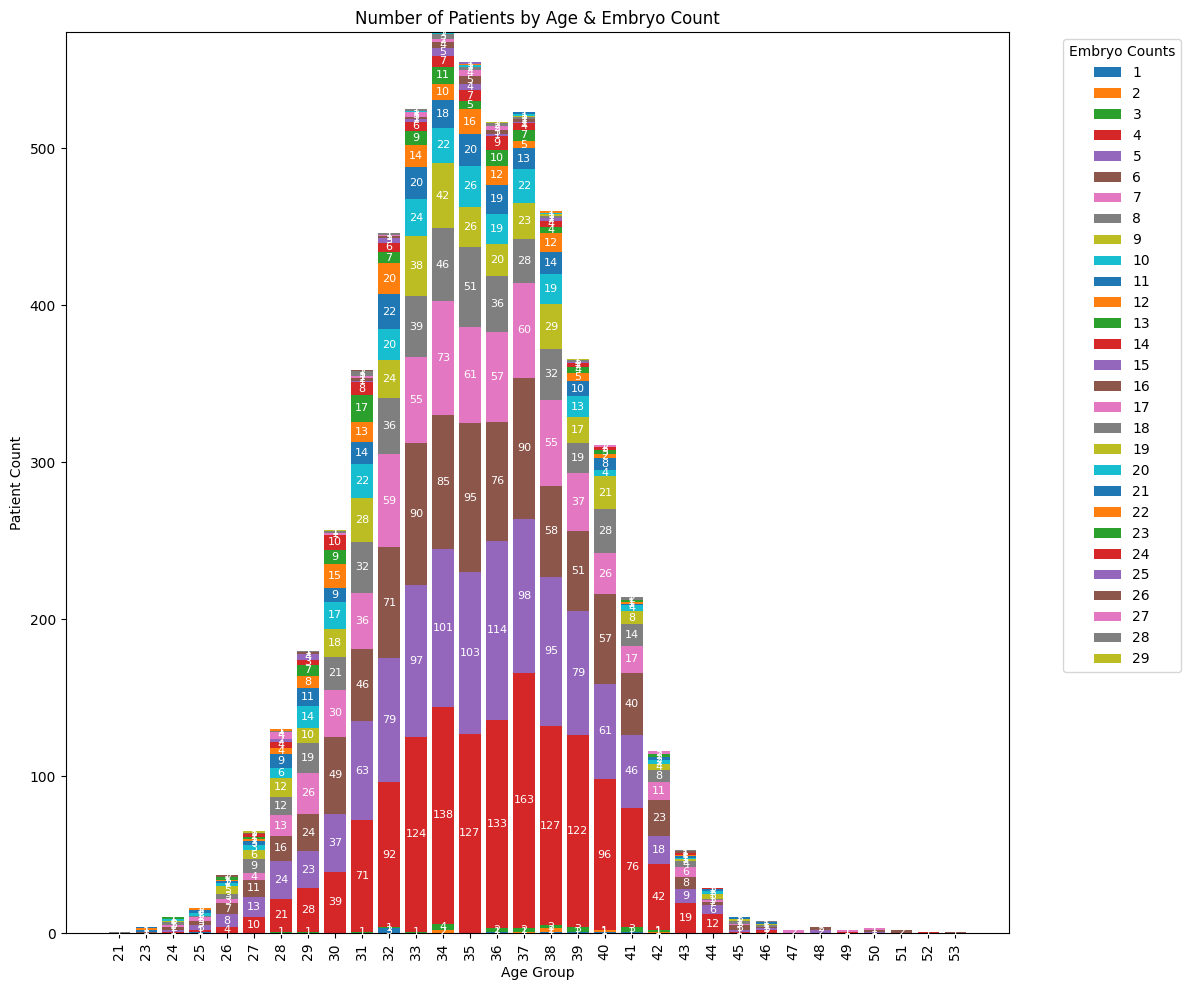

In [29]:
# Create pivot table: rows = age, columns = embryo count, values = patient count
pivot_df = fullEmbryoPtTotals.pivot_table(
    index="patient_age", columns="number_of_embryos",
    values="pts_w_embryo_count", fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 10))
x_position = np.arange(len(pivot_df.index))
bottom_values = np.zeros(len(pivot_df.index))

# Stack bars for each embryo count
# Note: the inner text labels use a loop over bar patches — this is matplotlib API,
# not a data-processing loop, so it's appropriate here.
for embryo_count in pivot_df.columns:
    bars = ax.bar(x_position, pivot_df[embryo_count], bottom=bottom_values, label=f"{embryo_count}")
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + h / 2,
                    str(int(h)), ha="center", va="center", fontsize=8, color="white")
    bottom_values += pivot_df[embryo_count].values

ax.set_xticks(x_position)
ax.set_xticklabels([str(int(a)) for a in pivot_df.index], rotation=90)
ax.set_ylabel("Patient Count")
ax.set_xlabel("Age Group")
ax.set_title("Number of Patients by Age & Embryo Count")
ax.legend(title="Embryo Counts", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 15. CCS Abnormalities — Unique Results

In [30]:
# Convert CCS columns to string type
age["CCS_interpretation"] = age["CCS_interpretation"].astype(str)
age["CCS_result"] = age["CCS_result"].astype(str)

# Filter to abnormal entries and get unique abnormality results
abnormalities_df = age[age["CCS_interpretation"] == "Abnormal"].reset_index(drop=True)
uniqueAbnormalities_df = abnormalities_df.drop_duplicates(subset="CCS_result").reset_index(drop=True)
uniqueAbnormalities_df

,patient_ID,embryo_ID,number_of_embryos,CCS_result,CCS_interpretation,maternal_age,paternal_age,morphology,embryo_age,sex,file_name,path
0,1468,3,5,"45XY, -16",Abnormal,34.0,*,6BB,6,XY,JTR8W-10-0342-10-BST3_S22_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
1,1468,5,5,"45XX, -22",Abnormal,34.0,*,3BB,6,XX,JTR8W-10-0342-10-BST5_S24_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211004...
2,1469,1,14,"45XX, -2",Abnormal,27.0,29,4AB,5,XX,JTRPJ-10-0343-10-AST1_S5_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211015...
3,1469,3,14,45XO,Abnormal,27.0,29,3BB,5,XO,JTRPJ-10-0343-10-AST3_S7_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211015...
4,1469,6,14,"45XY, -18",Abnormal,27.0,29,5AB,6,XY,JTRPJ-10-0343-10-AST6_S10_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2021/October_2021/211015...
...,...,...,...,...,...,...,...,...,...,...,...,...
1394,7442,5,5,"46XXY, -14",Abnormal,NaN,*,6AB,7,XXY,L53FB-9-2714-9-KAT5_S23_L001_R1_001.fastq.gz,K:/MiSeq5/MiSeqOutput/2023/December_2023/23120...
1395,7449,5,7,"44XX, -2 -12",Abnormal,41.0,42,4BB,6,XX,L53F7-9-2740-9-LGT5_S5_L001_R1_001.fastq.gz,K:/MiSeq6/MiSeqOutput/2023/December_2023/23120...
1396,7455,4,4,"44XY, -11 -20",Abnormal,39.0,35,3BB,6,XY,LBB2N-9-2768-9-JGT4_S5_L001_R1_001.fastq.gz,K:/MiSeq3/MiSeqOutput/2023/December_2023/23121...
1397,7458,2,4,"46XY, -7 +17",Abnormal,37.0,35,5AA,6,XY,LB96V-9-2782-9-SCT2_S10_L001_R1_001.fastq.gz,K:/MiSeq2/MiSeqOutput/2023/December_2023/23122...


In [31]:
uniqueAbnormalities_df.to_csv("uniqueAbnormalities.csv", index=False)
uniqueAbnormalities_df.to_csv("uniqueAbnormalities.txt", sep=",", index=False)

## 16. Per-Patient Aneuploidy Rate Calculation

For each patient:
1. Count total entries (embryo count)
2. Count total "Abnormal" entries
3. Aneuploidy rate = (abnormal / total) × 100%

**Vectorized approach:** use `groupby` + `agg` to compute counts in one pass instead of looping patient by patient.

In [32]:
# Old approach: nested loops over range(1468, 7462), iterrows() to count abnormals
# for j in range(1468, 7462):
#     tempdf = age.loc[age["patient_ID"] == j]
#     ...
#     for index, row in tempdf.iterrows():
#         if row["CCS_interpretation"] == "Abnormal":
#             abnormalCounter += 1
#     aneuploidyRate = (abnormalCounter / totals) * 100

# Vectorized: compute aneuploidy rate per patient without any loops
age_valid = age.dropna(subset="maternal_age").copy()

# Flag abnormal rows as 1/0
age_valid["is_abnormal"] = (age_valid["CCS_interpretation"] == "Abnormal").astype(int)

# Aggregate per patient: first maternal_age, first number_of_embryos, sum of abnormals
patient_summary = age_valid.groupby("patient_ID").agg(
    maternal_age=("maternal_age", "first"),
    number_of_embryos=("number_of_embryos", "first"),
    abnormal_count=("is_abnormal", "sum")
).reset_index()

patient_summary["Aneuploidy_Rate"] = (patient_summary["abnormal_count"] / patient_summary["number_of_embryos"]) * 100
patient_summary["maternal_age"] = patient_summary["maternal_age"].astype(int)

fullEntryWAneuploidyRate_df = patient_summary
fullEntryWAneuploidyRate_df

,patient_ID,maternal_age,number_of_embryos,abnormal_count,Aneuploidy_Rate
0,1468,34,5,2,40.000000
1,1469,27,14,7,50.000000
2,1471,32,4,2,50.000000
3,1472,39,4,3,75.000000
4,1473,41,4,1,25.000000
...,...,...,...,...,...
5774,7456,39,5,4,80.000000
5775,7457,33,7,3,42.857143
5776,7458,37,4,3,75.000000
5777,7460,32,4,1,25.000000


In [33]:
patientAge_vs_AneuploidyRate_df = fullEntryWAneuploidyRate_df[["maternal_age", "Aneuploidy_Rate"]]
patientAge_vs_AneuploidyRate_df

,maternal_age,Aneuploidy_Rate
0,34,40.000000
1,27,50.000000
2,32,50.000000
3,39,75.000000
4,41,25.000000
...,...,...
5774,39,80.000000
5775,33,42.857143
5776,37,75.000000
5777,32,25.000000


In [34]:
patientAge_vs_AneuploidyRate_df.to_csv("patientAge_vs_AneuploidyRate.csv", index=False)
patientAge_vs_AneuploidyRate_df.to_csv("patientAge_vs_AneuploidyRate.txt", sep=",", index=False)

## 17. Box Plot — Patient Age vs. Aneuploidy Rate

<Figure size 3000x600 with 0 Axes>

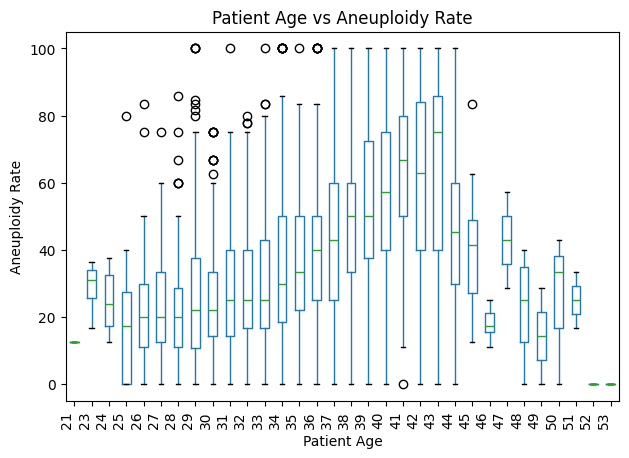

In [35]:
plt.figure(figsize=(30, 6))
patientAge_vs_AneuploidyRate_df.boxplot(column="Aneuploidy_Rate", by="maternal_age", grid=False)

plt.title("Patient Age vs Aneuploidy Rate")
plt.xlabel("Patient Age")
plt.ylabel("Aneuploidy Rate")
plt.suptitle("")  # Remove automatic pandas title
plt.tight_layout()
plt.xticks(rotation=90, ha="right")
plt.show()

## 18. Chromosome-Level Aneuploidy Counts

Extract the first two digits of each `CCS_result` string to identify the chromosome involved.  

Regex explanation:
- `r'^(\d{2})'` — `r` = raw string, `^` = start of string, `\d` = digit 0–9, `{2}` = exactly 2 occurrences

In [36]:
mono_tri_poly_somyCounts_df = pd.DataFrame()
mono_tri_poly_somyCounts_df["chromosome_number"] = abnormalities_df["CCS_result"].str.extract(r"^(\d{2})")
mono_tri_poly_somyCounts_df["chromosome_number"] = pd.to_numeric(mono_tri_poly_somyCounts_df["chromosome_number"], errors="coerce")

mono_tri_poly_somyCounts_df["chromosome_number"].describe()

count    14685.000000
mean        45.801771
std          1.098585
min         44.000000
25%         45.000000
50%         45.000000
75%         47.000000
max         48.000000
Name: chromosome_number, dtype: float64

In [37]:
# Count occurrences of each chromosome number and compute prevalence
mono_tri_poly_somyCounts_df = mono_tri_poly_somyCounts_df["chromosome_number"].value_counts().reset_index()

# 14685 = total abnormal chromosome findings in this dataset at time of analysis.
# Dataset-specific constant, not recomputed here; update if the source data changes.
mono_tri_poly_somyCounts_df["aneuploid_prevalence"] = (mono_tri_poly_somyCounts_df["count"]) / 14685 * 100
mono_tri_poly_somyCounts_df.to_csv("mono_tri_poly_somyCount.csv", index=False)
mono_tri_poly_somyCounts_df

,chromosome_number,count,aneuploid_prevalence
0,45,6944,47.286347
1,47,4535,30.881852
2,46,1501,10.221314
3,44,978,6.659857
4,48,727,4.950630


### 18.1 Single and Double Aneuploid Counts — Bar Chart

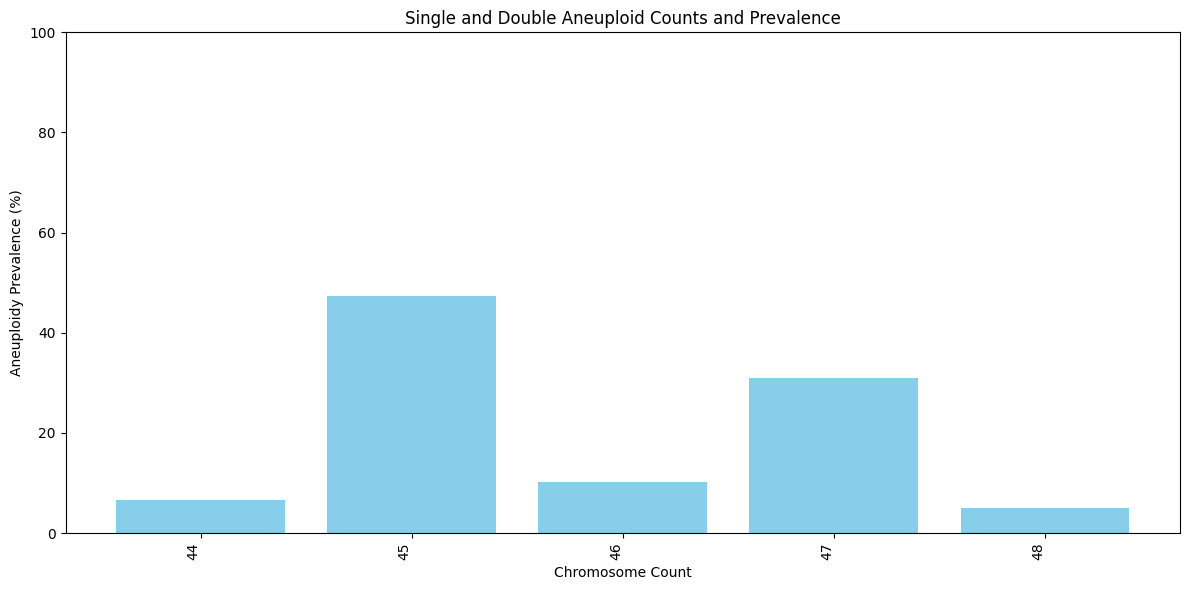

In [38]:
plt.figure(figsize=(12, 6))
plt.bar(mono_tri_poly_somyCounts_df["chromosome_number"],
        mono_tri_poly_somyCounts_df["aneuploid_prevalence"], color="skyblue")
plt.title("Single and Double Aneuploid Counts and Prevalence")
plt.xlabel("Chromosome Count")
plt.ylabel("Aneuploidy Prevalence (%)")
plt.ylim(0, 100)
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.show()

## 19. Extract Exact Chromosome Abnormalities from CCS_result

Parse the portion after the comma in `CCS_result` to get the specific abnormality type.  
Handle NaN entries (results without a comma) separately.

In [39]:
chromosome_Abnormalities_df = pd.DataFrame()
chromosome_Abnormalities_df["exact_chromsome_aneuploidy"] = abnormalities_df["CCS_result"].str.extract(r",\s*(.*)")

# Separate NaN rows (CCS_result values without a comma)
nan_rows_df = chromosome_Abnormalities_df[chromosome_Abnormalities_df["exact_chromsome_aneuploidy"].isna()]
chromosome_Abnormalities_df = chromosome_Abnormalities_df[chromosome_Abnormalities_df["exact_chromsome_aneuploidy"].notna()].copy()

# The NaN entries correspond to standalone results (e.g., 45X0, 47XXY, etc.)
index_series_NA = pd.Series(nan_rows_df.index)
nan_abnormalities_series = abnormalities_df["CCS_result"].loc[index_series_NA]
print(f"Entries without comma-separated abnormality: {len(nan_rows_df)}")
nan_abnormalities_series

Entries without comma-separated abnormality: 499


3         45XO
20       47XXY
31       47XXY
51        45XO
77        45XO
         ...  
14361     45XO
14382    47XYY
14404    47XXY
14477     45XO
14551     45XO
Name: CCS_result, Length: 499, dtype: object

In [40]:
# Again append the standalone abnormalities and reset index
chromosome_Abnormalities_df = pd.concat(
    [chromosome_Abnormalities_df, nan_abnormalities_series.rename("exact_chromsome_aneuploidy")],
    axis=0
).reset_index(drop=True)

chromosome_Abnormalities_df.to_csv("chromosome_Aneuploidy_list.csv", index=False)
chromosome_Abnormalities_df

,exact_chromsome_aneuploidy
0,-16
1,-22
2,-2
3,-18
4,+2
...,...
14680,45XO
14681,47XYY
14682,47XXY
14683,45XO


In [41]:
# Count occurrences of each unique abnormality
chromosome_Abnormalities_df = chromosome_Abnormalities_df["exact_chromsome_aneuploidy"].value_counts().reset_index()
chromosome_Abnormalities_df.columns = ["abnormality", "total_occurences"]
chromosome_Abnormalities_df.to_csv("chromosome_Abnormality_Count.csv", index=False)

print(f"Total abnormality occurrences: {chromosome_Abnormalities_df['total_occurences'].sum()}")

Total abnormality occurrences: 14685


## 20. Partial Chromosome (p/q Arm) Abnormalities

Filter for abnormalities involving chromosome arms (containing `p` or `q` in the result).

In [42]:
df_pq_actual = abnormalities_df[abnormalities_df["CCS_result"].str.contains(r"[pq]", na=False)]
df_pq_actual.to_csv("pq_arms.csv", index=False)
print(f"Entries with p/q arm abnormalities: {len(df_pq_actual)}")
df_pq_actual

Entries with p/q arm abnormalities: 65


,patient_ID,embryo_ID,number_of_embryos,CCS_result,CCS_interpretation,maternal_age,paternal_age,morphology,embryo_age,sex,file_name,path
290,1603,1,6,"45XY, -p22.2",Abnormal,30.0,37,4AB,5,XY,L5DYF-10-0736-10-HKIT1_S11_L001_R1_001.fastq.gz,K:/MiSeq6/MiSeqOutput/2023/September_2023/2309...
291,1603,2,6,"45XY, -p22.2",Abnormal,30.0,37,4AB,5,XY,L5DYF-10-0736-10-HKIT2_S12_L001_R1_001.fastq.gz,K:/MiSeq6/MiSeqOutput/2023/September_2023/2309...
292,1603,3,6,"45XY, -p22.2",Abnormal,30.0,37,5BB,5,XY,L5DYF-10-0736-10-HKIT3_S13_L001_R1_001.fastq.gz,K:/MiSeq6/MiSeqOutput/2023/September_2023/2309...
343,1636,2,8,"45XY, -19q",Abnormal,40.0,*,NaN,5,XY,JTT33-11-1832-11-JTRT2_S11_L001_R1_001.fastq.gz,K:/MiSeq3/MiSeqOutput/2021/October_2021/211008...
392,1657,3,5,"45XY, -1pter",Abnormal,43.0,49,3BB,5,XY,JWNLW-11-1877-11-JKRT3_S16_L001_R1_001.fastq.gz,K:/MiSeq2/MiSeqOutput/2021/October_2021/211026...
...,...,...,...,...,...,...,...,...,...,...,...,...
13419,7011,7,13,"45XY, -1q",Abnormal,NaN,40,4BB,5,XY,JWJ4P-9-1350-9-AZT7_S7_L001_R1_001.fastq.gz,K:/MiSeq3/MiSeqOutput/2022/January_2022/220115...
13424,7014,4,6,"45XX, -10q",Abnormal,NaN,40,4AB,5,XX,JWK2C-9-1353-9-SPT4_S13_L001_R1_001.fastq.gz,K:/MiSeq4/MiSeqOutput/2022/January_2022/220128...
13450,7021,6,7,"47XX, +2qter",Abnormal,NaN,45,4AB,7,XX,K4WRH-9-1378-9-SMMT6_S21_L001_R1_001.fastq.gz,K:/MiSeq3/MiSeqOutput/2022/February_2022/22021...
13452,7022,3,16,"45XX, -1q",Abnormal,34.0,37,3AB,5,XX,K6VBN-9-1380-9-ECT3_S10_L001_R1_001.fastq.gz,K:/MiSeq1/MiSeqOutput/2022/February_2022/22021...


## 21. Chromosome-Level Occurrence Counts (1–23)

Extract numeric chromosome identifiers from each abnormality string and tally occurrences.

**Vectorized approach:** use `explode` + `value_counts` instead of iterating row by row.

In [44]:
# Filter out entries with uppercase letters (sex chromosome notations like XXY, X0, etc.)
df_filtered = chromosome_Abnormalities_df[
    ~chromosome_Abnormalities_df["abnormality"].str.contains(r"[A-Z]", regex=True)
][["abnormality", "total_occurences"]].copy()

# Extract all chromosome numbers (1-23) from each abnormality string
df_filtered["chromosomes"] = df_filtered["abnormality"].str.findall(r"\b(1[0-9]|2[0-3]|\d)\b")

# Old approach: nested loop over rows and chromosomes
# chromosome_counts = {}
# for _, row in df_filtered.iterrows():
#     for chrom in row['chromosomes']:
#         chrom = int(chrom)
#         chromosome_counts[chrom] = chromosome_counts.get(chrom, 0) + row['total_occurences']

# Vectorized: explode the list column, then aggregate
df_exploded = df_filtered.explode("chromosomes")
df_exploded = df_exploded.dropna(subset="chromosomes")  # drop rows where findall matched nothing
df_exploded["chromosomes"] = df_exploded["chromosomes"].astype(int)
chromosome_counts_series = df_exploded.groupby("chromosomes")["total_occurences"].sum()

# Build final DataFrame with all chromosomes 1-23
chromosome_df = pd.DataFrame({"chromosome": range(1, 24)})
chromosome_df["total_occurrences"] = chromosome_df["chromosome"].map(chromosome_counts_series).fillna(0).astype(int)

# Manual correction: the regex above cannot capture sex-chromosome notations (X/Y),
# so chromosome 23 is manually set to the verified count (492) from the full source data.
chromosome_df.loc[chromosome_df["chromosome"] == 23, "total_occurrences"] = 492

chromosome_df

,chromosome,total_occurrences
0,1,469
1,2,703
2,3,371
3,4,742
4,5,400
5,6,477
6,7,623
7,8,733
8,9,477
9,10,471


In [45]:
print(f"Total occurrences across all chromosomes: {chromosome_df['total_occurrences'].sum()}")

# 17566 = total chromosome-level findings in this dataset at time of analysis.
# Dataset-specific constant, not recomputed here; update if the source data changes.
chromosome_df["prevalence%"] = (chromosome_df["total_occurrences"] / 17566) * 100
chromosome_df.to_csv("chromosomes_prevalence.csv", index=False)
chromosome_df

Total occurrences across all chromosomes: 17568


,chromosome,total_occurrences,prevalence%
0,1,469,2.669931
1,2,703,4.002049
2,3,371,2.112035
3,4,742,4.224069
4,5,400,2.277126
5,6,477,2.715473
6,7,623,3.546624
7,8,733,4.172834
8,9,477,2.715473
9,10,471,2.681316


### 21.1 Aneuploid Prevalence by Chromosome — Bar Chart

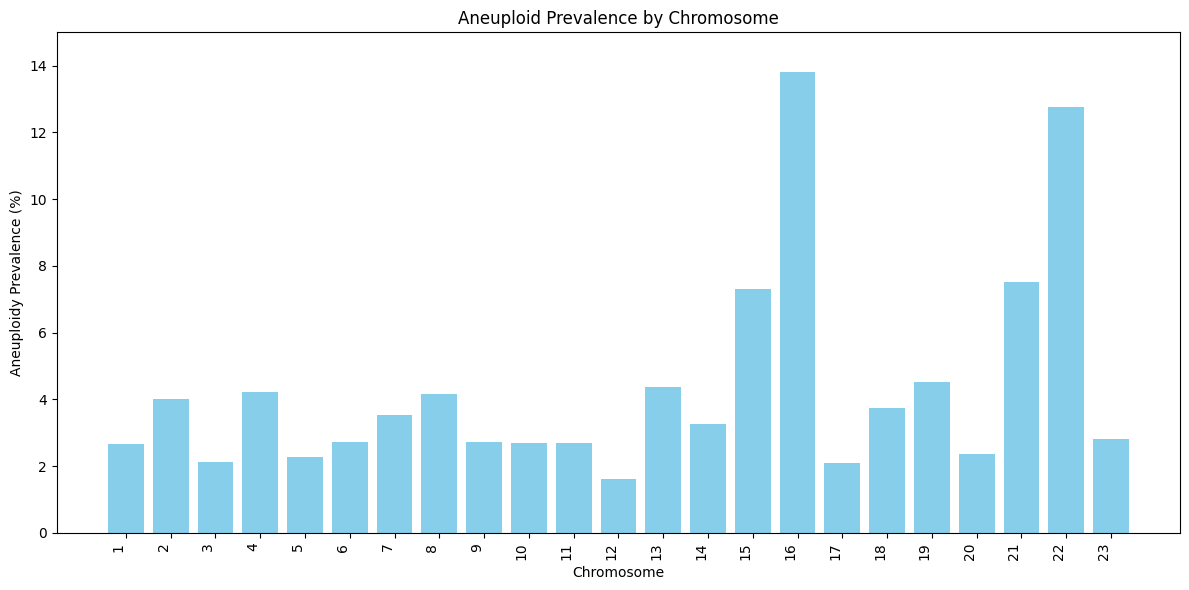

In [46]:
plt.figure(figsize=(12, 6))
plt.bar(chromosome_df["chromosome"], chromosome_df["prevalence%"], color="skyblue")
plt.title("Aneuploid Prevalence by Chromosome")
plt.xlabel("Chromosome")
plt.ylabel("Aneuploidy Prevalence (%)")
plt.ylim(0, 15)
plt.xticks(ticks=chromosome_df["chromosome"], labels=chromosome_df["chromosome"], rotation=90, ha="right")
plt.tight_layout()
plt.show()

## 22. Separate X and Y Chromosome Prevalence

Represent X as chromosome 23 and Y as chromosome 24 for visualization.

In [47]:
XYchromsome_df = chromosome_df.copy()
XYchromsome_df = XYchromsome_df[XYchromsome_df["chromosome"] != 23]  # Remove combined chr23 row

# Split the combined chr23 count into X and Y using verified counts from the source data
# (same regex limitation as above: string matching alone can't distinguish X from Y).
new_rows = pd.DataFrame([
    {"chromosome": 23, "total_occurrences": 466, "prevalence%": 2.66336},  # X
    {"chromosome": 24, "total_occurrences": 26, "prevalence%": 0.14784},   # Y
])
XYchromsome_df = pd.concat([XYchromsome_df, new_rows], ignore_index=True)
XYchromsome_df

,chromosome,total_occurrences,prevalence%
0,1,469,2.669931
1,2,703,4.002049
2,3,371,2.112035
3,4,742,4.224069
4,5,400,2.277126
5,6,477,2.715473
6,7,623,3.546624
7,8,733,4.172834
8,9,477,2.715473
9,10,471,2.681316


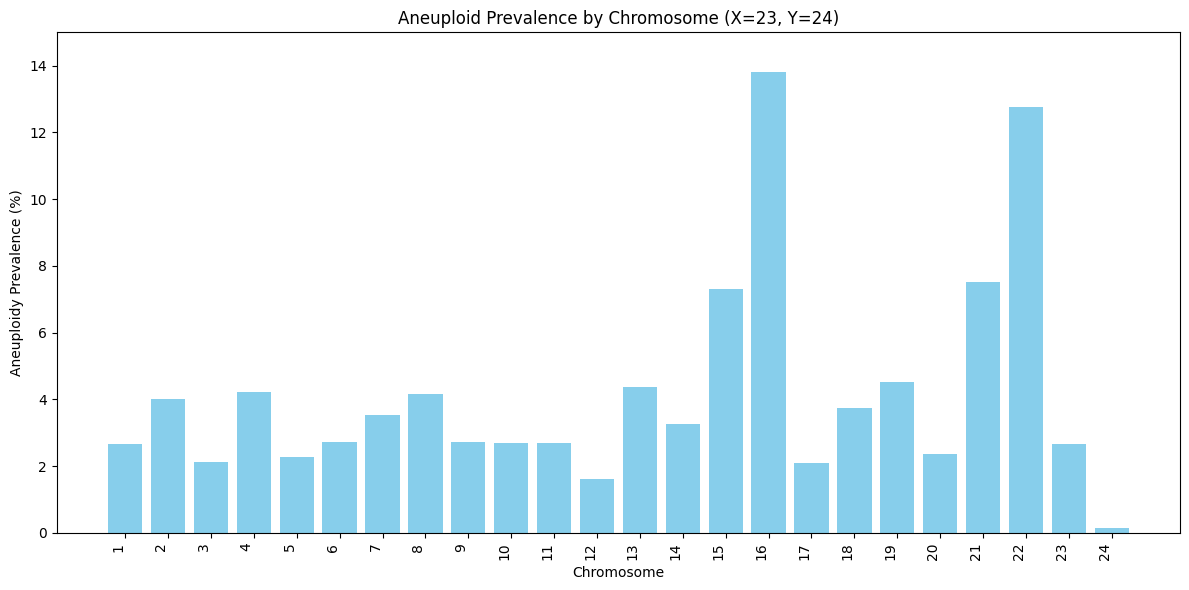

In [48]:
plt.figure(figsize=(12, 6))
plt.bar(XYchromsome_df["chromosome"], XYchromsome_df["prevalence%"], color="skyblue")
plt.title("Aneuploid Prevalence by Chromosome (X=23, Y=24)")
plt.xlabel("Chromosome")
plt.ylabel("Aneuploidy Prevalence (%)")
plt.ylim(0, 15)
plt.xticks(ticks=XYchromsome_df["chromosome"], labels=XYchromsome_df["chromosome"], rotation=90, ha="right")
plt.tight_layout()
plt.show()

## 23. Chromosome Prevalence — Sorted Descending

In [49]:
sorted_chromosome_df = chromosome_df.sort_values(by="prevalence%", ascending=False)
sorted_chromosome_df.to_csv("chromosomes_prevalence_descending.csv", index=False)
sorted_chromosome_df

,chromosome,total_occurrences,prevalence%
15,16,2426,13.810771
21,22,2242,12.763293
20,21,1321,7.520209
14,15,1283,7.303883
18,19,795,4.525788
12,13,766,4.360697
3,4,742,4.224069
7,8,733,4.172834
1,2,703,4.002049
17,18,658,3.745873
